# Problem 3: 
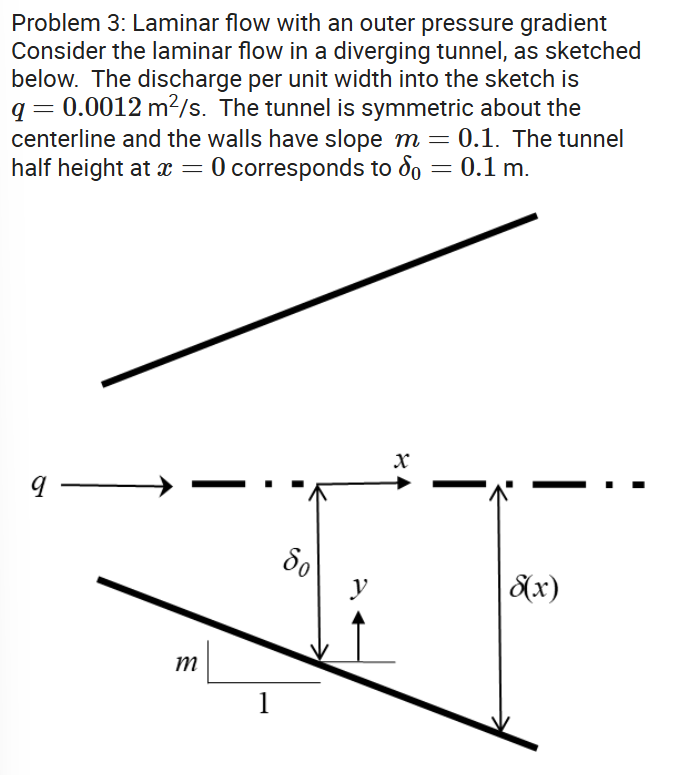
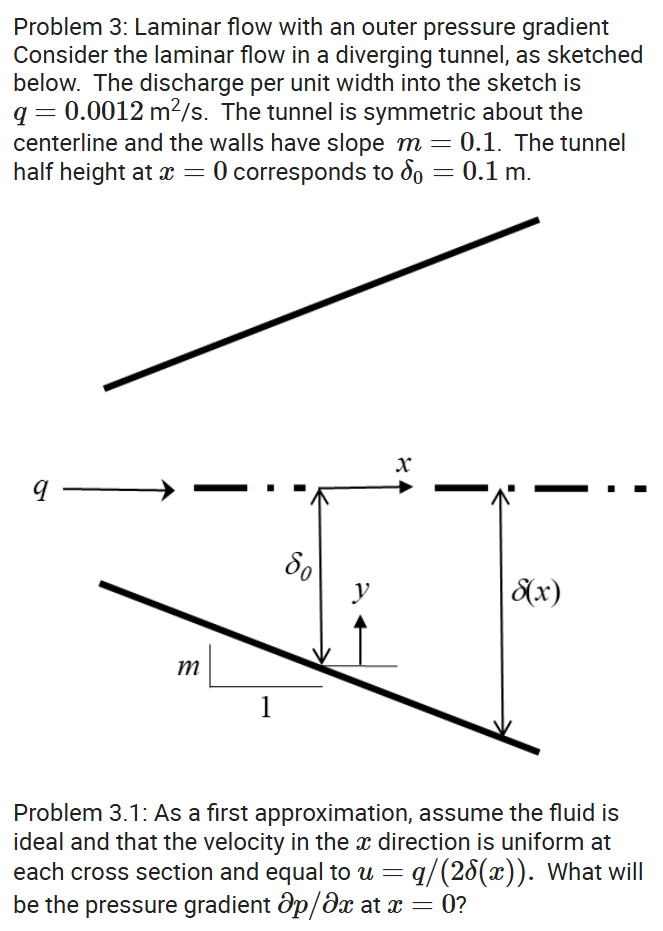

In [1]:
import numpy as np
import sympy as sp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from scipy.special import erfc, erfcinv
from scipy.integrate import solve_ivp

In [3]:
# Given data
g = 9.81                    # gravitational acceleration (m/s^2)
viscosity = 1.3*10**-6      # kinematic viscosity of water (m^2/s)    
rho_water = 1000            # density of water (kg/m^3)
kappa = 0.4                 # von Karman constant
rho_air = 1.2               # air density (kg/m^3)
viscosity_air = 1.5*10**-5  # kinematic viscosity of air (m^2/s)

q = 0.0012
m = 0.1
x = 0
delta_0 = 0.1

#### Question 3.1
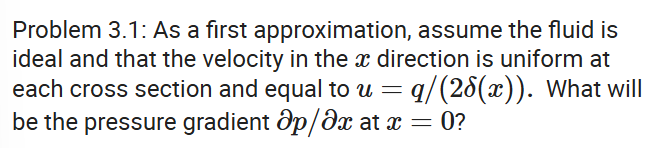

In [29]:
delta_x = 0.1
u = q/(2*delta_x)
print(f"Horizontal velocity: {u:.2e}")

Horizontal velocity: 6.00e-03


In [30]:
from scipy.integrate import quad
# Displacement thickness at t=0
def integrand():
    u = q/(2*delta_0)
    return u

# Calculate the displacement thickess
gradient, _ = quad(integrand, 0, np.inf)      # result, estimated error

# Print the result
print(f"Gradient: {gradient:.4f} m")
print(f"Gradient?: {gradient/viscosity:.4f} m")


TypeError: integrand() takes 0 positional arguments but 1 was given

#### Question 3.2
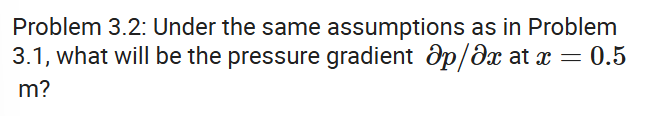

In [9]:
pressure_gradient = -m * g * rho_water
print(f"Pressure gradient {pressure_gradient}")

Pressure gradient -981.0000000000001


#### Question 3.3
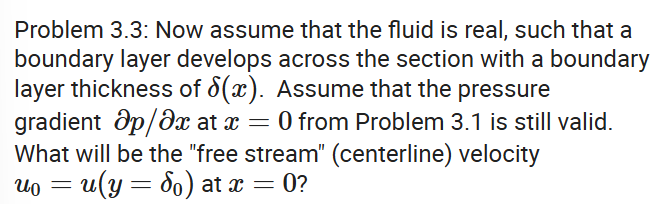

In [32]:
eta = lambda y: y/delta_0
u_0 = q/(2*delta_0)

pressure_grad = 0.15
param_hat =  -(delta_0**2 / (viscosity * u_0 * rho_water) * pressure_grad)

Feta = lambda y: 2*eta(y) -2 * eta(y)**3 + eta(y)**4
Geta = lambda y: 1/6 * (eta(y)- 3*eta(y)**2+3*eta(y)**3-eta(y)**4)

y1 = 0.02
u_bound = (Feta(y1) + param_hat * Geta(y1)) * u_0

print(f"Velocity in boundary layer: {u_bound} m/s")

Velocity in boundary layer: -0.017378707692307697 m/s


#### Question 3.4
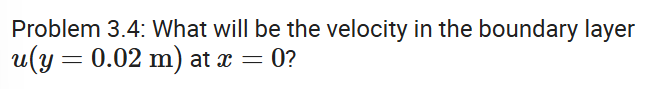

#### Question 3.5
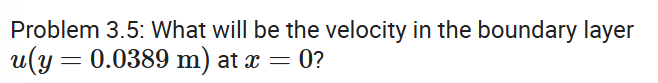

### STOP

In [39]:
u_0 = q/(2*delta_0)
delta = lambda x: 4.8 * np.sqrt(viscosity * x / u_0)

from scipy.integrate import quad
# Displacement thickness at t=0
def integrand(x):
    u = q/(2*4.8 * np.sqrt(viscosity * x / u_0))
    return u

# Calculate the displacement thickess
gradient, _ = quad(integrand, 0, np.inf)      # result, estimated error

print(gradient)

grad = gradient* u_0 * -rho_water
print(grad)

pres_hat = delta_0**2/viscosity *gradient
print(pres_hat)

-3.731036995313515e-12
2.2386221971881087e-11
-2.8700284579334736e-08


C:\Users\natal\AppData\Local\Temp\ipykernel_23244\195305839.py:11: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  gradient, _ = quad(integrand, 0, np.inf)      # result, estimated error
